In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from fastai.vision.all import *
import regex as re

In [2]:
df = pd.read_csv(r'D:\Traffic\labels_processed.csv')

In [4]:
df['Names']

0              Speed limit (5km/h)
1             Speed limit (15km/h)
2             Speed limit (30km/h)
3             Speed limit (40km/h)
4             Speed limit (50km/h)
5             Speed limit (60km/h)
6             Speed limit (70km/h)
7             speed limit (80km/h)
8         Dont Go straight or left
9        Dont Go straight or Right
10                Dont Go straight
11                    Dont Go Left
12           Dont Go Left or Right
13                   Dont Go Right
14         Dont overtake from Left
15                        No Uturn
16                          No Car
17                         No horn
18            Go straight or right
19                     Go straight
20                         Go Left
21                Go Left or right
22                        Go Right
23                       keep Left
24                      keep Right
25            Roundabout mandatory
26              watch out for cars
27                            Horn
28               Bic

In [8]:
def label_function(dpath):
    class_name = re.findall(r'(\d+)_.*\.png$', dpath.name)
    class_id = int(class_name[0])
    return df['Names'][class_id]

In [9]:
fname = Path(r'D:/Traffic/traffic_Data/DATA/1/001_0001.png')

In [10]:
label_function(fname)

'Speed limit (15km/h)'

In [11]:
signs = DataBlock(blocks = (ImageBlock, CategoryBlock),
                  get_items = get_image_files,
                  splitter = RandomSplitter(seed = 42),
                  get_y = label_function,
                  item_tfms = Resize(224),
                  batch_tfms = aug_transforms(size = 224, min_scale = 0.75, do_flip = False))

In [12]:
dataloaders_dict = {}

In [15]:
path = Path(r'D:\Traffic\traffic_Data_processed\DATA')

In [16]:
dls = signs.dataloaders(path)

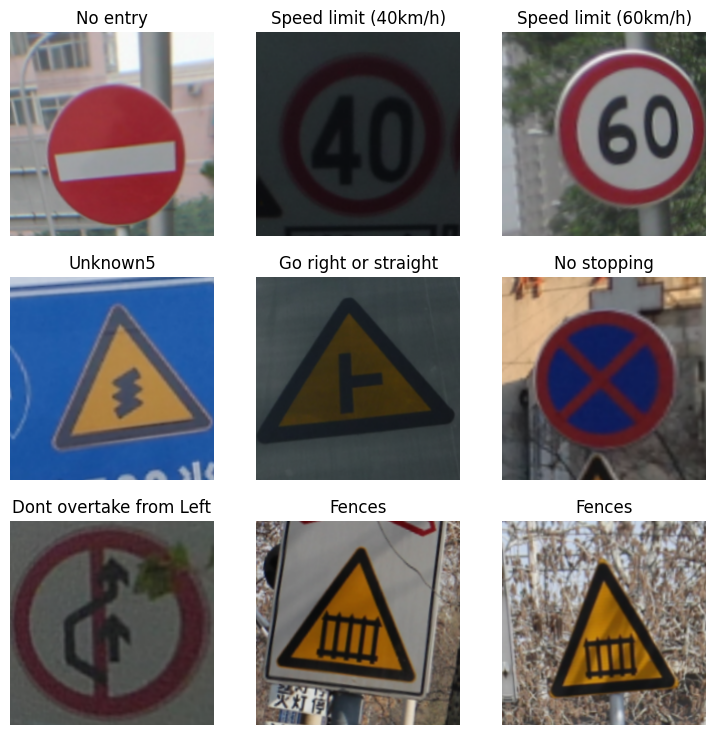

In [17]:
dls.show_batch()

In [18]:
signs.summary(path)

Setting-up type transforms pipelines
Found 4151 items
2 datasets of sizes 3321,830
Setting up Pipeline: PILBase.create
Setting up Pipeline: label_function -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}


Building one sample
  Pipeline: PILBase.create
    starting from
      D:\Traffic\traffic_Data_processed\DATA\35\35_8.png
    applying PILBase.create gives
      PILImage mode=RGB size=149x138
  Pipeline: label_function -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}

    starting from
      D:\Traffic\traffic_Data_processed\DATA\35\35_8.png
    applying label_function gives
      Dangerous curve to the left
    applying Categorize -- {'vocab': None, 'sort': True, 'add_na': False}
 gives
      TensorCategory(3)

Final sample: (PILImage mode=RGB size=149x138, TensorCategory(3))


Found 4151 items
2 datasets of sizes 3321,830
Setting up Pipeline: PILBase.create
Setting up Pipeline: label_function -> Categorize -- {'vocab': None, 'sort': True, 'add_na': Fa

In [19]:
from fastprogress.fastprogress import master_bar, progress_bar
master_bar, progress_bar = master_bar, progress_bar

In [20]:
baseline_model = vision_learner(dls, arch = resnet34, metrics = error_rate)

In [21]:
baseline_model.fine_tune(4)

epoch,train_loss,valid_loss,error_rate,time
0,2.401334,0.454024,0.119277,01:41


epoch,train_loss,valid_loss,error_rate,time
0,0.362838,0.075158,0.020482,00:23
1,0.165041,0.017034,0.003614,00:23
2,0.075002,0.005455,0.000000,00:23
3,0.033530,0.004705,0.000000,00:23


In [22]:
baseline_model.export('baseline_model(2).pkl')

In [23]:
path_test = Path(r'D:\Traffic\traffic_Data_processed\TEST')

In [24]:
signs_test = DataBlock(blocks = (ImageBlock, CategoryBlock),
                  get_items = get_image_files,
                  splitter = None,
                  get_y = label_function,
                  item_tfms = Resize(224),
                  batch_tfms = aug_transforms(size = 224, min_scale = 0.75, do_flip = False))

In [25]:
dls_test = signs_test.dataloaders(path_test)

KeyError: 55